In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
df = pd.read_csv('../data/mymoviedb.csv',lineterminator='\n')
df['Release_Date']=pd.to_datetime(df['Release_Date']).dt.year
df['Genre']=df['Genre'].str.split(', ')

In [2]:
# 1.cheacking duplicates
# 2.cheacking null
df.isnull().sum() 
# there is no null any column 
# there is no any duplicated  row

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [3]:
df.describe()
# removing unecessary details 
df.drop(['Original_Language',"Overview","Poster_Url"],axis=1,inplace=True)

In [4]:
# create labels for voting
edges=[df['Vote_Average'].min(),df['Vote_Average'].quantile(0.25),df['Vote_Average'].quantile(0.50),df['Vote_Average'].quantile(0.75),df['Vote_Average'].max()]
labels=['Not popular',"below Avrage","Average_popular",'popular']
df['Vote_Average']=pd.cut(df['Vote_Average'],edges,labels=labels,duplicates='drop')



In [5]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [6]:
df=df.explode('Genre')
df['Genre']=df['Genre'].astype('category')
plt.style.use('seaborn-v0_8-poster')

# most freqeny genre of movies

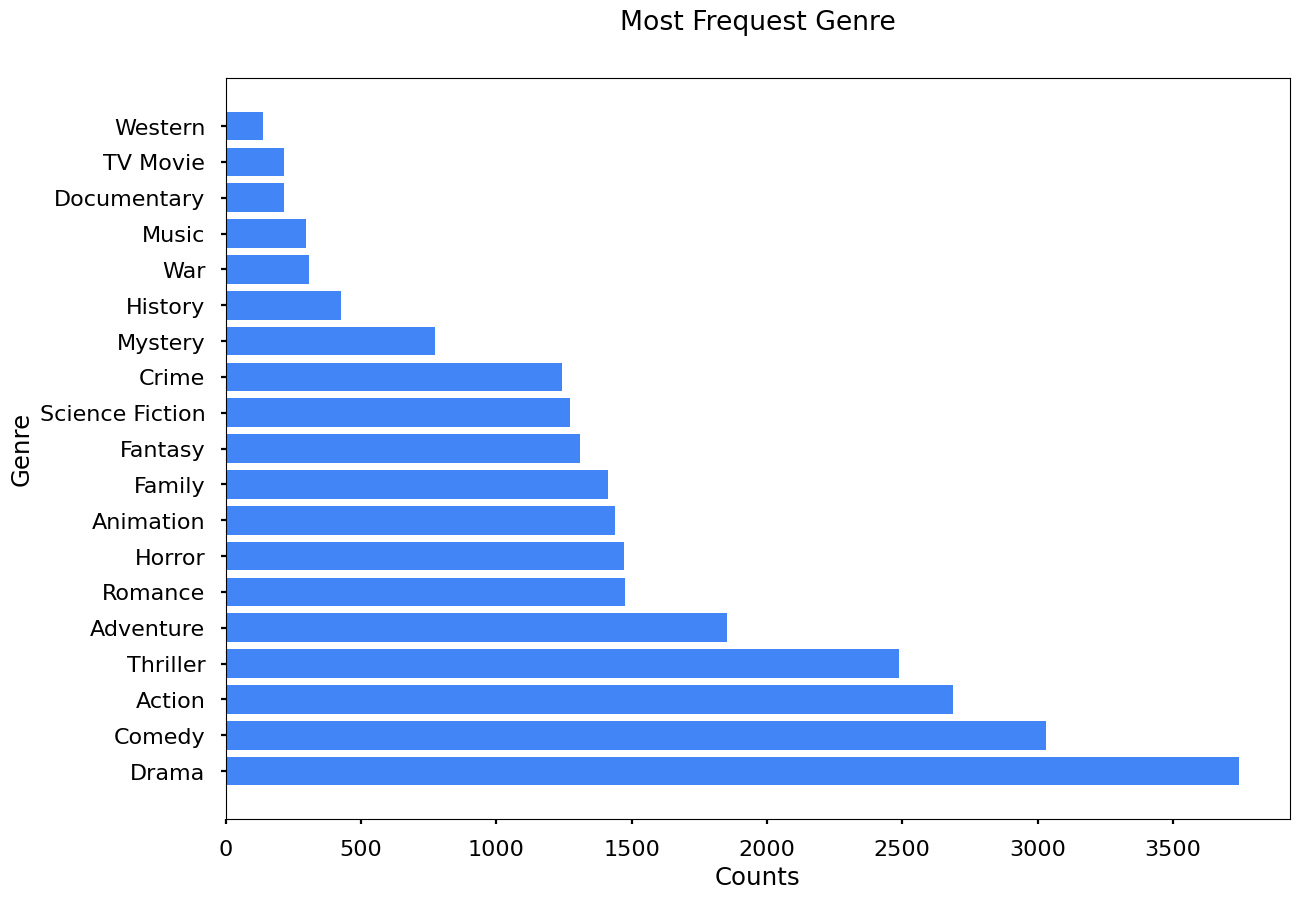

In [12]:
genre_name=df['Genre'].value_counts().index
genre_count=df['Genre'].value_counts().sort_values(ascending=False).values
plt.barh(genre_name,genre_count,color='#4285f7')
plt.Figure(figsize=(18,9))
plt.xticks(rotation=0)
plt.title("Most Frequest Genre",pad=35)
plt.tight_layout()
plt.ylabel('Genre')
plt.xlabel('Counts')
plt.savefig("../charts/gnerre.png",dpi=100)
plt.show()

# state of movies

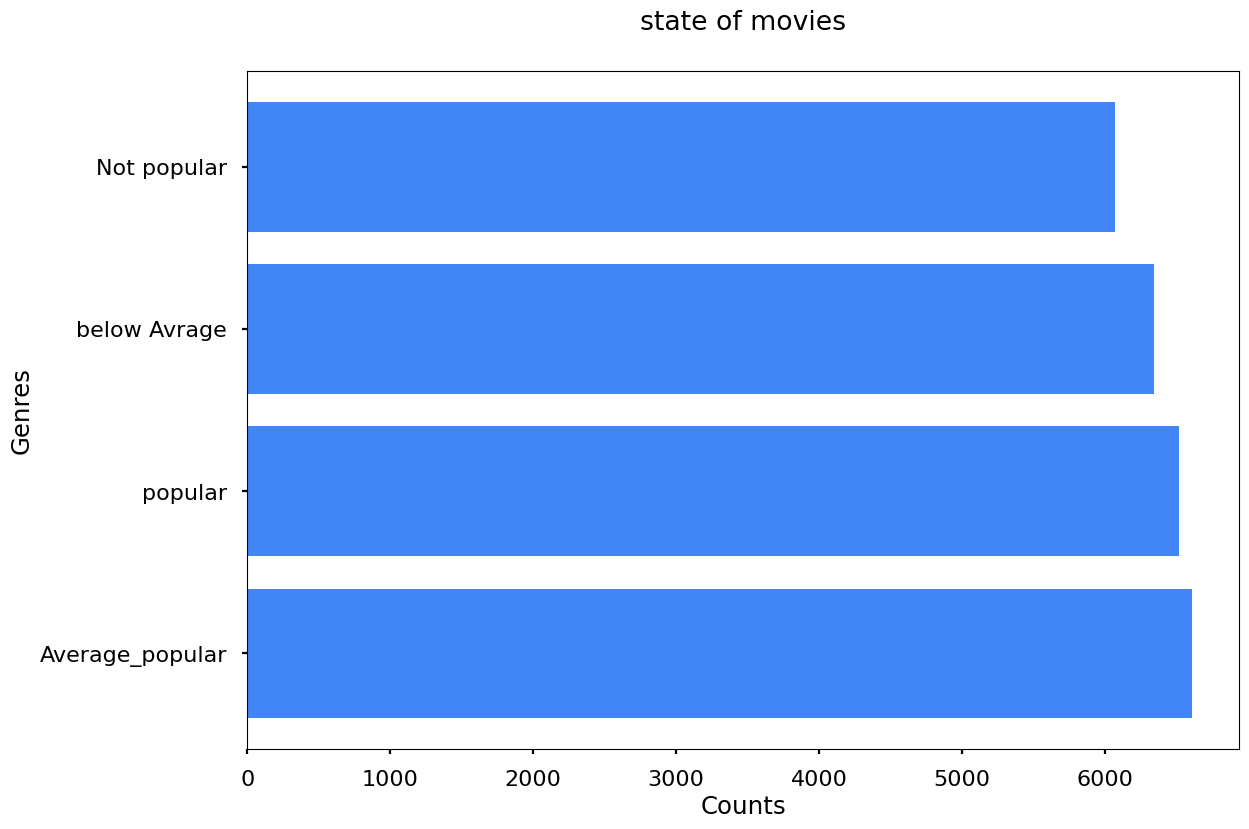

In [14]:
labels_for_movies=df['Vote_Average'].value_counts().index
count_for_movies=df['Vote_Average'].value_counts().values
plt.barh(labels_for_movies,count_for_movies,color='#4285f7')
plt.xlabel("Counts")
plt.ylabel('Genres')
plt.title("state of movies",pad=30)
plt.savefig("../charts/movies_are.png",dpi=100)
plt.show()


# most popular movies

In [ ]:
df[df['Popularity']==df['Popularity'].max()]


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


# Lowest genre  

In [164]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
9825,2021,The United States vs. Billie Holiday,13.354,152,Average_popular,Music
9825,2021,The United States vs. Billie Holiday,13.354,152,Average_popular,Drama
9825,2021,The United States vs. Billie Holiday,13.354,152,Average_popular,History
9826,1984,Threads,13.354,186,popular,War
9826,1984,Threads,13.354,186,popular,Drama
9826,1984,Threads,13.354,186,popular,Science Fiction


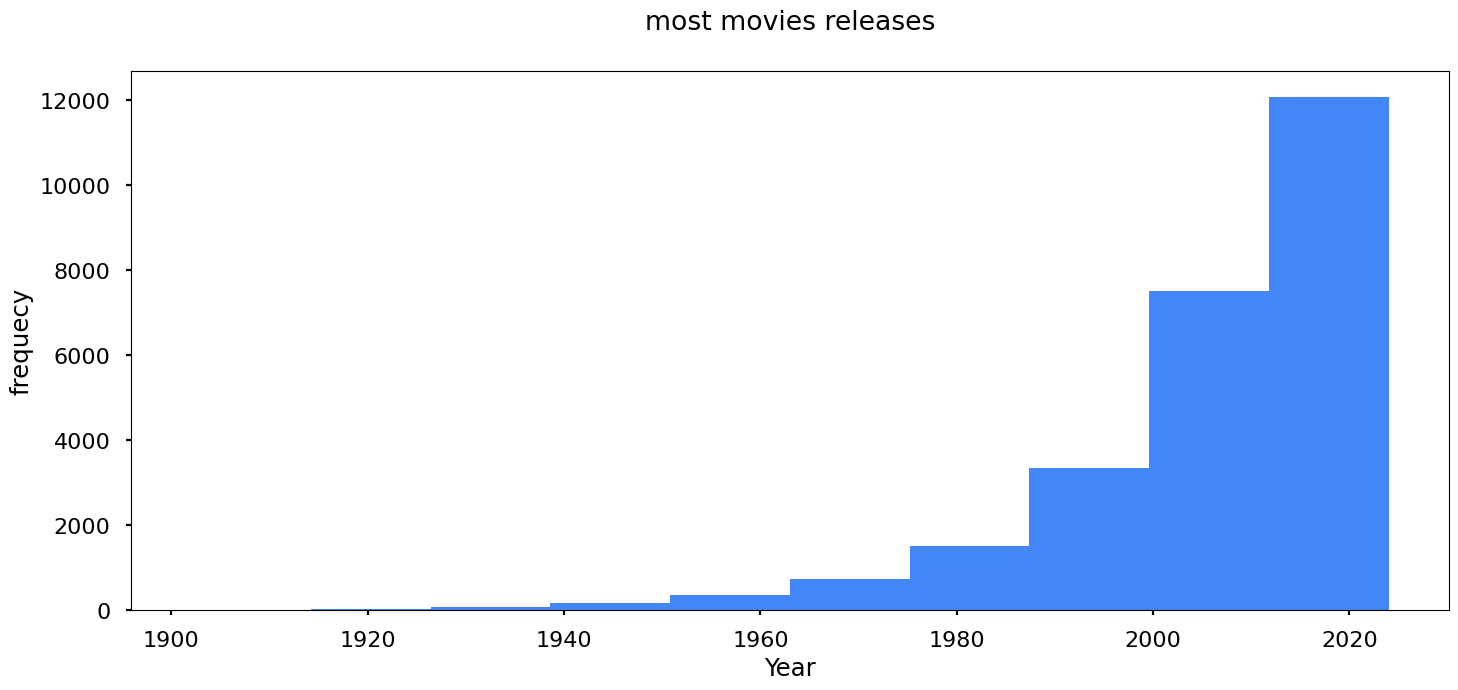

In [16]:
plt.figure(figsize=(17,7))
plt.hist(df['Release_Date'],color='#4287f5')
plt.title("most movies releases",pad=30)
plt.xlabel("Year")
plt.ylabel('frequecy')
plt.savefig("../charts/most_movies.png",dpi=100)
plt.show()



# summary
- **Most frequent Genre:** In NetFlix The Most frequent Genre is Drama

- **state of movies:** The most movies are Popular

- **which movie most popular:** Spider-Man: No Way Home and popularity Rate is 5083.954

- **which movie lowes popular:** The United States vs. Billie Holiday  and popularity Rate 13.354


